In [1]:
from pathlib import Path
from torch import multiprocessing
from tqdm import tqdm
import soundfile as sf

In [2]:
import numpy as np
import pandas as pd
import time

In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib import colors
import datetime as dt

In [4]:
import sys

# append the path of the
# parent directory
sys.path.append('..')
sys.path.append('../src/')
sys.path.append('../src/models/bat_call_detector/batdetect2/')

import src.batdt2_pipeline as batdetect2_pipeline
from pipeline import pipeline
from utils.utils import gen_empty_df
from cfg import get_config

In [5]:
def run_models(file_mappings):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a .csv.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    bd_dets = pd.DataFrame()
    for i in tqdm(range(len(file_mappings))):
        cur_seg = file_mappings[i]
        bd_annotations_df = cur_seg['model']._run_batdetect(cur_seg['audio_seg']['audio_file'])
        bd_offsetted = pipeline._correct_annotation_offsets(
                bd_annotations_df,
                cur_seg['original_file_name'],
                cur_seg['audio_seg']['offset']
            )
        bd_dets = pd.concat([bd_dets, bd_offsetted])
        
    return bd_dets

def apply_models(file_path_mappings, cfg):
    """
    Runs the batdetect2 model to detect bat search-phase calls in the provided audio segments and saves detections into a dataframe

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()
    cfg : `dict`
        - A dictionary of pipeline parameters:
        - models is the models in the pipeline that are being used.

    Returns
    ------------
    bd_preds : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    process_pool = multiprocessing.Pool(cfg['num_processes'])

    bd_dets = tqdm(
            process_pool.imap(apply_model, file_path_mappings, chunksize=1), 
            desc=f"Applying BatDetect2",
            total=len(file_path_mappings),
        )
    
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(bd_dets, ignore_index=True)
    
    return bd_preds

def apply_model(file_mapping):
    """
    Runs the batdetect2 model on a single provided audio segmens and corrects the offsets according the segment.

    Parameters
    ------------
    file_mappings : `List`
        - List of dictionaries generated by initialize_mappings()

    Returns
    ------------
    corrected_bd_dets : `pandas.DataFrame`
        - A DataFrame of detections that will also be saved in the provided output_dir under the above csv_name
        - 7 columns in this DataFrame: start_time, end_time, low_freq, high_freq, detection_confidence, event, input_file
        - Detections are always specified w.r.t their input_file; earliest start_time can be 0 and latest end_time can be 1795.
        - Events are always "Echolocation" as we are using a model that only detects search-phase calls.
    """

    print(f"Processing {file_mapping['audio_seg']['audio_file']}")
    bd_dets = file_mapping['model']._run_batdetect(file_mapping['audio_seg']['audio_file'])
    corrected_bd_dets = pipeline._correct_annotation_offsets(
                                                            bd_dets,
                                                            file_mapping['original_file_name'],
                                                            file_mapping['audio_seg']['offset']
                                                            )

    return corrected_bd_dets

In [6]:
def run_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = run_models(file_path_mappings)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

def apply_pipeline_on_file(file, cfg):
    bd_preds = pd.DataFrame()

    if not cfg['output_dir'].is_dir():
        cfg['output_dir'].mkdir(parents=True, exist_ok=True)
    if not cfg['tmp_dir'].is_dir():
        cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

    cfg["csv_filename"] = f"batdetect2_pipeline_{file.name.split('.')[0]}"
    print(f"Generating detections for {file.name}")
    segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([file], cfg)
    file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
    bd_preds = apply_models(file_path_mappings, cfg)
    if cfg['save']:
        batdetect2_pipeline._save_predictions(bd_preds, cfg['output_dir'], cfg)
    batdetect2_pipeline.delete_segments(segmented_file_paths)

    return bd_preds

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

run_pipeline_on_file(input_file, cfg)

Generating detections for 20220728_080000.WAV


100%|██████████| 60/60 [02:53<00:00,  2.89s/it]


,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file
0,5.8035,5.8132,37500,43789,Pipistrellus nathusii,0.459,0.577,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,6.1035,6.1126,37500,47445,Pipistrellus nathusii,0.378,0.538,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,6.2085,6.2189,37500,46328,Pipistrellus nathusii,0.405,0.536,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
3,6.4205,6.4304,37500,44472,Pipistrellus nathusii,0.482,0.611,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
4,6.5275,6.5377,36640,47744,Pipistrellus nathusii,0.450,0.591,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
...,...,...,...,...,...,...,...,...,...,...
86,1794.1435,1794.1580,22890,29234,Nyctalus leisleri,0.488,0.648,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
87,1794.3755,1794.3911,22890,27858,Nyctalus leisleri,0.565,0.629,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
88,1794.6075,1794.6260,22890,27947,Nyctalus leisleri,0.361,0.540,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
89,1794.7165,1794.7290,25468,29839,Nyctalus leisleri,0.611,0.676,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...


In [ ]:
cfg = get_config()
cfg['audio_file'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['num_processes'] = 12
cfg['should_csv'] = False
cfg['save'] = True

segmented_file_paths = pipeline._segment_input_audio(cfg)
pipeline._apply_models(cfg, segmented_file_paths)

In [7]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 30.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x76f0cdebd460>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
   'offset': 30.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x76f0cdebd460>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [11]:
segmented_file_paths

[{'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
  'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
  'offset': 0.0},
 {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
  'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
  'offset': 30.0},
 {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
  'audio_file': PosixPath('../output/20220728_080000__60.00_90.00.wav'),
  'offset': 60.0},
 {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
  'audio_file': PosixPath('../output/20220728_080000__90.00_120.00.wav'),
  'offset': 90.0},
 {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
  'audio_file': PosixPath('../output/20220728_080000__120.00_150.00.wav'),
  'offset': 120.0},
 {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_

In [18]:
input = file_path_mappings[:16]

In [20]:
run_models(input)

100%|██████████| 16/16 [00:45<00:00,  2.86s/it]


,start_time,end_time,low_freq,high_freq,class,class_prob,det_prob,individual,event,input_file
0,5.8035,5.8132,37500,43789,Pipistrellus nathusii,0.459,0.577,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,6.1035,6.1126,37500,47445,Pipistrellus nathusii,0.378,0.538,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,6.2085,6.2189,37500,46328,Pipistrellus nathusii,0.405,0.536,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
3,6.4205,6.4304,37500,44472,Pipistrellus nathusii,0.482,0.611,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
4,6.5275,6.5377,36640,47744,Pipistrellus nathusii,0.450,0.591,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
...,...,...,...,...,...,...,...,...,...,...
25,434.7665,434.7757,37500,43382,Pipistrellus nathusii,0.429,0.510,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
0,457.2815,457.2918,38359,45322,Pipistrellus nathusii,0.529,0.593,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
1,457.3945,457.4041,39218,48455,Pipistrellus nathusii,0.580,0.636,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...
2,457.6025,457.6109,37500,45876,Pipistrellus nathusii,0.371,0.529,-1,Echolocation,../../Downloads/recover-20220728/Carp/20220728...


In [19]:
num_processes = 16
pool = multiprocessing.Pool(processes=num_processes)
chunks_per_processor = 1
print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
start = time.time()
results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                desc=f"Applying BatDetect2", total=len(input),)
bd_preds = gen_empty_df() 
bd_preds = pd.concat(results, ignore_index=True)
end = time.time()
print(f'Time taken: {end-start}s')

Parsing 16 chunks with 16 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/16 [00:00<?, ?it/s]

Processing ../output/20220728_080000__120.00_150.00.wavProcessing ../output/20220728_080000__90.00_120.00.wavProcessing ../output/20220728_080000__0.00_30.00.wavProcessing ../output/20220728_080000__30.00_60.00.wavProcessing ../output/20220728_080000__60.00_90.00.wavProcessing ../output/20220728_080000__210.00_240.00.wavProcessing ../output/20220728_080000__240.00_270.00.wavProcessing ../output/20220728_080000__180.00_210.00.wavProcessing ../output/20220728_080000__150.00_180.00.wavProcessing ../output/20220728_080000__270.00_300.00.wavProcessing ../output/20220728_080000__300.00_330.00.wavProcessing ../output/20220728_080000__330.00_360.00.wavProcessing ../output/20220728_080000__390.00_420.00.wavProcessing ../output/20220728_080000__420.00_450.00.wavProcessing ../output/20220728_080000__360.00_390.00.wav














Processing ../output/20220728_080000__450.00_480.00.wav


Applying BatDetect2: 100%|██████████| 16/16 [03:09<00:00, 11.86s/it]

Time taken: 189.8488965034485s


In [9]:
time_taken = np.zeros(8)
num_processes = 12
chunksizes = np.array([10, 15, 30, 60])
for i in np.arange(0, 4, 1):
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = chunksizes[i]
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken[i] = end-start

time_taken

Parsing 60 chunks with 12 processors and 10 chunks per processor


Applying BatDetect2:   0%|          | 0/60 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wavProcessing ../output/20220728_080000__300.00_330.00.wavProcessing ../output/20220728_080000__1500.00_1530.00.wavProcessing ../output/20220728_080000__900.00_930.00.wavProcessing ../output/20220728_080000__1200.00_1230.00.wavProcessing ../output/20220728_080000__600.00_630.00.wav





Processing ../output/20220728_080000__330.00_360.00.wav
Processing ../output/20220728_080000__1530.00_1560.00.wav
Processing ../output/20220728_080000__630.00_660.00.wav
Processing ../output/20220728_080000__1230.00_1260.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__930.00_960.00.wav
Processing ../output/20220728_080000__1560.00_1590.00.wav
Processing ../output/20220728_080000__360.00_390.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__1260.00_1290.00.wav
Processing ../output/20220728_080000__660.00_690.00.wav
Processing ../output/20220728_080000__960.0

Applying BatDetect2: 100%|██████████| 60/60 [11:13<00:00, 11.22s/it]   

Time taken: 673.3549525737762s


...

Applying BatDetect2:   0%|          | 0/60 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav
Processing ../output/20220728_080000__240.00_270.00.wav
Processing ../output/20220728_080000__270.00_300.00.wav
Processing ../output/20220728_080000__300.00_330.00.wav
Processing ../output/20220728_080000__330.00_360.00.wav
Processing ../output/20220728_080000__360.00_390.00.wav
Processing ../output/20220728_080000__390.00_420.00.wav
Processing ../output/20220728_080000__420.00_450.00.wav
Processing ../output/20220728_080000__450.00_480.00.wav
Processing ../output/20220728_080000__480.00_510.00.wav
Processing ../output/20220728_080000__510.00_540.00.wav


Applying BatDetect2: 100%|██████████| 60/60 [02:34<00:00,  2.58s/it]  

Time taken: 154.67726135253906s


array([673.35495257, 643.52966738, 518.19070411, 154.67726135,
         0.        ,   0.        ,   0.        ,   0.        ])

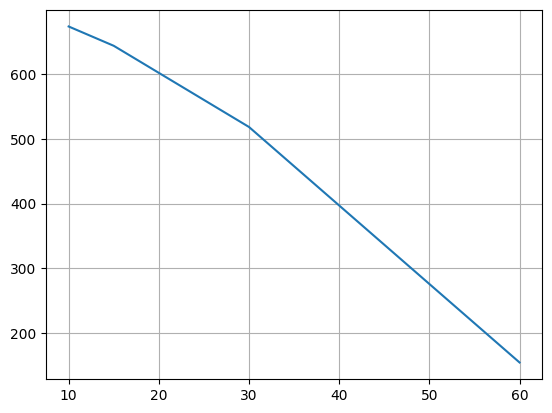

In [10]:
plt.plot(chunksizes, time_taken[:4])
plt.grid(which='both')
plt.show()

In [10]:
file_path_mappings

[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x76f0cdebd460>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
   'offset': 30.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x76f0cdebd460>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__60.00_90.00.wav'),
   'offset': 60.0},
  'model': <models.bat_call_dete

In [11]:
input = file_path_mappings[:10]

In [12]:
time_taken_test2 = np.zeros(10)
for i in np.arange(1, 10+1):
    num_processes = 12
    pool = multiprocessing.Pool(processes=num_processes)
    chunks_per_processor = i
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunks_per_processor} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunks_per_processor), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test2[i-1] = end-start

time_taken_test2

Parsing 10 chunks with 12 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wavProcessing ../output/20220728_080000__30.00_60.00.wavProcessing ../output/20220728_080000__60.00_90.00.wavProcessing ../output/20220728_080000__120.00_150.00.wavProcessing ../output/20220728_080000__180.00_210.00.wavProcessing ../output/20220728_080000__90.00_120.00.wavProcessing ../output/20220728_080000__150.00_180.00.wavProcessing ../output/20220728_080000__210.00_240.00.wavProcessing ../output/20220728_080000__270.00_300.00.wav

Processing ../output/20220728_080000__240.00_270.00.wav









Applying BatDetect2: 100%|██████████| 10/10 [01:56<00:00, 11.65s/it]

Time taken: 116.5029764175415s


...

Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav
Processing ../output/20220728_080000__240.00_270.00.wav
Processing ../output/20220728_080000__270.00_300.00.wav


Applying BatDetect2: 100%|██████████| 10/10 [00:27<00:00,  2.73s/it]

Time taken: 27.351380348205566s


array([116.50297642, 111.36135125, 104.42613792,  97.68345571,
        89.20938396,  79.80344987,  66.09418011,  53.33677101,
        41.53410602,  27.35138035])

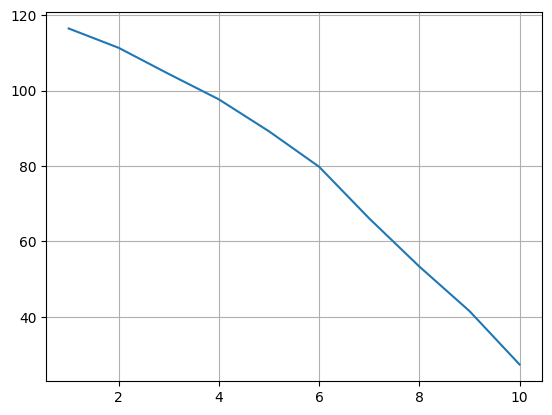

In [13]:
plt.plot(np.arange(1,11,1, dtype=int), time_taken_test2)
plt.grid(which='both')
plt.show()

In [14]:
input = file_path_mappings[:10]

In [15]:
num_processes = 1
pool = multiprocessing.Pool(processes=num_processes)
chunksize_default, extra = divmod(len(input), num_processes*4)
if extra:
    chunksize_default += 1
chunksize_custom = 10
(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')

'Parsing 10 chunks with 1 processors and 10 chunks per processor'

In [16]:
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 10
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 10 chunks with 1 processors and 10 chunks per processor


Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav
Processing ../output/20220728_080000__240.00_270.00.wav
Processing ../output/20220728_080000__270.00_300.00.wav


Applying BatDetect2: 100%|██████████| 10/10 [00:28<00:00,  2.82s/it]

...

Applying BatDetect2:   0%|          | 0/10 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav
Processing ../output/20220728_080000__240.00_270.00.wav
Processing ../output/20220728_080000__270.00_300.00.wav


Applying BatDetect2: 100%|██████████| 10/10 [00:28<00:00,  2.83s/it]

Time taken: 28.33946418762207s


array([28.17416883, 28.81664562, 27.7516675 , 29.63562346, 27.49964547,
       26.4347713 , 28.80590868, 28.61804342, 27.17969871, 28.46751857,
       28.2267592 , 29.09532785, 27.23637056, 26.41858554, 28.0849731 ,
       28.33946419])

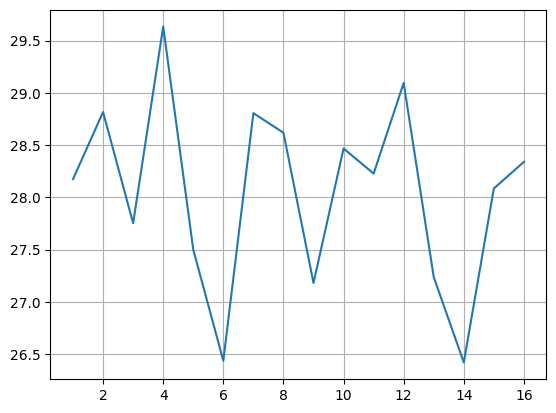

In [17]:
plt.plot(1+np.arange(multiprocessing.cpu_count(), dtype=int), time_taken_test3)
plt.grid(which='both')
plt.show()

In [18]:
input = file_path_mappings[:4]
num_processes = 4
pool = multiprocessing.Pool(processes=num_processes)
chunksize_custom = 4
print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
start = time.time()
results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                desc=f"Applying BatDetect2", total=len(input),)
bd_preds = gen_empty_df() 
bd_preds = pd.concat(results, ignore_index=True)
end = time.time()
print(f'Time taken: {end-start}s')

Parsing 4 chunks with 4 processors and 4 chunks per processor


Applying BatDetect2:   0%|          | 0/4 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav


Applying BatDetect2: 100%|██████████| 4/4 [00:11<00:00,  2.96s/it]

Time taken: 11.854116916656494s


In [19]:
input = file_path_mappings[:1]
time_taken_test3 = np.zeros(multiprocessing.cpu_count())
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    chunksize_custom = 1
    print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
    start = time.time()
    results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                    desc=f"Applying BatDetect2", total=len(input),)
    bd_preds = gen_empty_df() 
    bd_preds = pd.concat(results, ignore_index=True)
    end = time.time()
    print(f'Time taken: {end-start}s')
    time_taken_test3[i] = end-start
time_taken_test3

Parsing 1 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/1 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2: 100%|██████████| 1/1 [00:03<00:00,  3.90s/it]

Time taken: 3.90750789642334s


...

Applying BatDetect2:   0%|          | 0/1 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2: 100%|██████████| 1/1 [00:03<00:00,  3.61s/it]

Time taken: 3.616175889968872s


array([3.9075079 , 3.67080998, 3.58684468, 3.49927711, 3.6770978 ,
       3.51377797, 3.41962361, 3.61067057, 3.689821  , 3.43037105,
       3.67303252, 3.63770628, 3.77117825, 3.79831386, 3.68315935,
       3.61617589])

In [13]:
file_path_mappings

[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_30.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x76f0cdebd460>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__30.00_60.00.wav'),
   'offset': 30.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x76f0cdebd460>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__60.00_90.00.wav'),
   'offset': 60.0},
  'model': <models.bat_call_dete

In [ ]:
start = time.time()
run_models(file_path_mappings[:8])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 8/8 [00:22<00:00,  2.77s/it]


Baseline time 22.133423566818237s
Parsing 8 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav


In [8]:
input = file_path_mappings[:8]
time_taken_test3 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = i+1
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = tqdm(pool.imap(apply_model, input, chunksize=chunksize_custom), 
                        desc=f"Applying BatDetect2", total=len(input),)
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test3[i,j] = end-start
        print(time_taken_test3)

Parsing 8 chunks with 1 processors and 1 chunks per processor


Applying BatDetect2:   0%|          | 0/8 [00:00<?, ?it/s]

Processing ../output/20220728_080000__0.00_30.00.wav


Applying BatDetect2:  12%|█▎        | 1/8 [00:03<00:24,  3.54s/it]

Processing ../output/20220728_080000__30.00_60.00.wav


...

[[21.90602469 20.9963851  20.55987692 21.78240347 21.16723371 21.46665001
  21.41767049 21.14316678]
 [70.78392434 71.89678407 57.89699888 70.1109581  58.42405009 46.34282494
  34.07307673 22.23637295]
 [80.04693246 67.34761167 78.23928046 70.11575603 58.83455825 45.74470568
  35.20441628 22.19505572]
 [87.65619254 86.06131339 79.61051011 68.54412913 60.27095747 47.23931026
  35.60773826 23.34996247]
 [85.28723097 86.2609756  79.07587242 69.70076966 59.03130245 46.94757152
  34.36734366 22.39413095]
 [86.85596132 86.77326822 80.37299109 71.70972252 56.31331277 47.20491481
  33.85908866 21.95031595]
 [83.20941496 86.96140957 79.31695104 70.41030741 57.5564487  47.42262125
  35.533288   20.97153854]
 [92.19518161 85.80047965 80.05045938 63.50406098 60.22483897 45.72356915
  34.07789683 22.75017834]
 [92.17354488 85.84407139 78.41428661 70.91483665 58.08436251 46.11562538
  33.68841147 22.88014054]
 [92.69882202 87.06106973 79.52821589 68.40409923 60.3287518  44.26378584
  31.73286915 20.

Applying BatDetect2:   0%|          | 0/8 [00:00<?, ?it/s]

Processing ../output/20220728_080000__30.00_60.00.wav
Processing ../output/20220728_080000__60.00_90.00.wav
Processing ../output/20220728_080000__90.00_120.00.wav
Processing ../output/20220728_080000__120.00_150.00.wav
Processing ../output/20220728_080000__150.00_180.00.wav
Processing ../output/20220728_080000__180.00_210.00.wav
Processing ../output/20220728_080000__210.00_240.00.wav


Applying BatDetect2: 100%|██████████| 8/8 [00:22<00:00,  2.81s/it]

[[21.90602469 20.9963851  20.55987692 21.78240347 21.16723371 21.46665001
  21.41767049 21.14316678]
 [70.78392434 71.89678407 57.89699888 70.1109581  58.42405009 46.34282494
  34.07307673 22.23637295]
 [80.04693246 67.34761167 78.23928046 70.11575603 58.83455825 45.74470568
  35.20441628 22.19505572]
 [87.65619254 86.06131339 79.61051011 68.54412913 60.27095747 47.23931026
  35.60773826 23.34996247]
 [85.28723097 86.2609756  79.07587242 69.70076966 59.03130245 46.94757152
  34.36734366 22.39413095]
 [86.85596132 86.77326822 80.37299109 71.70972252 56.31331277 47.20491481
  33.85908866 21.95031595]
 [83.20941496 86.96140957 79.31695104 70.41030741 57.5564487  47.42262125
  35.533288   20.97153854]
 [92.19518161 85.80047965 80.05045938 63.50406098 60.22483897 45.72356915
  34.07789683 22.75017834]
 [92.17354488 85.84407139 78.41428661 70.91483665 58.08436251 46.11562538
  33.68841147 22.88014054]
 [92.69882202 87.06106973 79.52821589 68.40409923 60.3287518  44.26378584
  31.73286915 20.

In [9]:
time_taken_test3

array([[21.90602469, 20.9963851 , 20.55987692, 21.78240347, 21.16723371,
        21.46665001, 21.41767049, 21.14316678],
       [70.78392434, 71.89678407, 57.89699888, 70.1109581 , 58.42405009,
        46.34282494, 34.07307673, 22.23637295],
       [80.04693246, 67.34761167, 78.23928046, 70.11575603, 58.83455825,
        45.74470568, 35.20441628, 22.19505572],
       [87.65619254, 86.06131339, 79.61051011, 68.54412913, 60.27095747,
        47.23931026, 35.60773826, 23.34996247],
       [85.28723097, 86.2609756 , 79.07587242, 69.70076966, 59.03130245,
        46.94757152, 34.36734366, 22.39413095],
       [86.85596132, 86.77326822, 80.37299109, 71.70972252, 56.31331277,
        47.20491481, 33.85908866, 21.95031595],
       [83.20941496, 86.96140957, 79.31695104, 70.41030741, 57.5564487 ,
        47.42262125, 35.533288  , 20.97153854],
       [92.19518161, 85.80047965, 80.05045938, 63.50406098, 60.22483897,
        45.72356915, 34.07789683, 22.75017834],
       [92.17354488, 85.84407139

In [ ]:
start = time.time()
run_models(file_path_mappings[:2])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 2/2 [00:05<00:00,  2.97s/it]


Baseline time 5.9445343017578125s
Parsing 2 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav


In [8]:
input = file_path_mappings[:2]
time_taken_test4 = np.zeros((multiprocessing.cpu_count(), len(input)))
for i in np.arange(multiprocessing.cpu_count()):
    num_processes = int(i+1)
    pool = multiprocessing.Pool(processes=num_processes)
    for j in np.arange(len(input)):
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test4[i,j] = end-start
        print(time_taken_test4)

Processing ../output/20220728_080000__0.00_30.00.wav


Parsing 2 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__30.00_60.00.wav
[[6.11690331 0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]]
Parsing 2 chunks with 1 processors and 2 chunks per processor
Processing ../output/20220728_080000__0.00_30.00.wav
Processing ../output/20220728_080000__30.00_60.00.wav
[[6.11690331 6.02642441]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0.        ]
 [0.         0

In [9]:
time_taken_test4

array([[ 6.11690331,  6.02642441],
       [17.26366377,  6.12925982],
       [19.47801614,  6.80864263],
       [18.99749994,  6.3272059 ],
       [17.21060753,  6.24917626],
       [18.45046854,  6.46406436],
       [19.71888328,  6.58081245],
       [19.47544885,  6.57263899],
       [18.51257396,  7.01790476],
       [17.07885242,  6.65018082],
       [19.35100746,  6.72236013],
       [18.37091684,  6.49454904],
       [19.53009748,  6.39957166],
       [19.20145702,  6.36788654],
       [18.77198648,  6.59933758],
       [18.92657614,  6.52569985]])

In [10]:
input_file = Path('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')

cfg = get_config()
cfg['segment_duration'] = 60.0
cfg['input_audio'] = input_file
cfg['tmp_dir'] = Path('../output')
cfg['output_dir'] = Path('../output_dir')
cfg['run_model'] = True
cfg['num_processes'] = 4
cfg['should_csv'] = False
cfg['save'] = True

# apply_pipeline_on_file(input_file, cfg)
bd_preds = pd.DataFrame()

if not cfg['output_dir'].is_dir():
    cfg['output_dir'].mkdir(parents=True, exist_ok=True)
if not cfg['tmp_dir'].is_dir():
    cfg['tmp_dir'].mkdir(parents=True, exist_ok=True)

cfg["csv_filename"] = f"batdetect2_pipeline_{input_file.name.split('.')[0]}"
print(f"Generating detections for {input_file.name}")
segmented_file_paths = batdetect2_pipeline.generate_segmented_paths([input_file], cfg)
file_path_mappings = batdetect2_pipeline.initialize_mappings(segmented_file_paths, cfg)
file_path_mappings[:2]

Generating detections for 20220728_080000.WAV


[{'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__0.00_60.00.wav'),
   'offset': 0.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x7ee29d18b550>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')},
 {'audio_seg': {'input_filepath': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV'),
   'audio_file': PosixPath('../output/20220728_080000__60.00_120.00.wav'),
   'offset': 60.0},
  'model': <models.bat_call_detector.model_detector.BatCallDetector at 0x7ee29d18b550>,
  'original_file_name': PosixPath('../../Downloads/recover-20220728/Carp/20220728_080000.WAV')}]

In [ ]:
start = time.time()
run_models(file_path_mappings[:4])
end = time.time()
print(f'Baseline time {end-start}s')

100%|██████████| 4/4 [00:22<00:00,  5.62s/it]


Baseline time 22.506182432174683s


In [11]:
input = file_path_mappings[:2]
time_taken_test5 = np.zeros((4, len(input)))
for i in np.arange(4):
    for j in np.arange(len(input)):
        num_processes = int(i+1)
        pool = multiprocessing.Pool(processes=num_processes)
        chunksize_custom = int(j+1)
        print(f'Parsing {len(input)} chunks with {num_processes} processors and {chunksize_custom} chunks per processor')
        start = time.time()
        results = (pool.map(apply_model, input, chunksize=chunksize_custom))
        bd_preds = gen_empty_df() 
        bd_preds = pd.concat(results, ignore_index=True)
        end = time.time()
        # print(f'Time taken: {end-start}s')
        time_taken_test5[i,j] = end-start
        print(time_taken_test5)

Processing ../output/20220728_080000__0.00_60.00.wav
Parsing 2 chunks with 1 processors and 1 chunks per processor
Processing ../output/20220728_080000__60.00_120.00.wav
[[11.80253816  0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Processing ../output/20220728_080000__0.00_60.00.wav
Parsing 2 chunks with 1 processors and 2 chunks per processor
Processing ../output/20220728_080000__60.00_120.00.wav
[[11.80253816 11.83994794]
 [ 0.          0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Processing ../output/20220728_080000__0.00_60.00.wavProcessing ../output/20220728_080000__60.00_120.00.wav

Parsing 2 chunks with 2 processors and 1 chunks per processor
[[11.80253816 11.83994794]
 [37.92887998  0.        ]
 [ 0.          0.        ]
 [ 0.          0.        ]]
Processing ../output/20220728_080000__0.00_60.00.wav
Parsing 2 chunks with 2 processors and 2 chunks per processor
Processing ../output/20220728_080000__60.00_120.

In [12]:
time_taken_test5

array([[11.80253816, 11.83994794],
       [37.92887998, 12.06153703],
       [33.9676125 , 12.50932789],
       [37.76716161, 12.72175193]])